In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Load the dataset
df = pd.read_csv('../../data/raw/bay_of_bengal_interpolated.csv')

# Basic info
print("Dataset Shape:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())
print("\nData Types:")
print(df.dtypes)
print("\nFirst 5 rows:")
print(df.head())
print("\nLast 5 rows:")
print(df.tail())

Dataset Shape: (1096, 11)

Column Names:
['Date', 'Latitude', 'Longitude', 'Region', 'SubRegion', 'Sampling_Method', 'Unit', 'Density_Class', 'Original_Concentration', 'Interpolated_Concentration', 'Is_Interpolated']

Data Types:
Date                           object
Latitude                      float64
Longitude                     float64
Region                         object
SubRegion                      object
Sampling_Method                object
Unit                           object
Density_Class                  object
Original_Concentration        float64
Interpolated_Concentration    float64
Is_Interpolated                  bool
dtype: object

First 5 rows:
         Date   Latitude  Longitude         Region       SubRegion  \
0  2018-01-01  20.614227  86.119419  Bay of Bengal  Coastal Waters   
1  2018-01-02  12.274566  93.014420  Bay of Bengal     Andaman Sea   
2  2018-01-03  20.867708  85.374231  Bay of Bengal  Coastal Waters   
3  2018-01-04  21.132283  85.702571  Bay of

In [8]:
# Missing values analysis
print("Missing Values per Column:")
print(df.isnull().sum())
print(f"\nTotal missing values: {df.isnull().sum().sum()}")
print(f"Percentage of missing values: {(df.isnull().sum().sum() / (df.shape[0] * df.shape[1])) * 100:.2f}%")

# Duplicate analysis
print(f"\nDuplicate rows: {df.duplicated().sum()}")

# Unique values per column
print("\nUnique values per column:")
for col in df.columns:
    print(f"{col}: {df[col].nunique()}")

Missing Values per Column:
Date                            0
Latitude                        0
Longitude                       0
Region                          0
SubRegion                       0
Sampling_Method                 0
Unit                            0
Density_Class                   0
Original_Concentration        508
Interpolated_Concentration      0
Is_Interpolated                 0
dtype: int64

Total missing values: 508
Percentage of missing values: 4.21%

Duplicate rows: 0

Unique values per column:
Date: 1096
Latitude: 1078
Longitude: 1096
Region: 1
SubRegion: 3
Sampling_Method: 1
Unit: 1
Density_Class: 5
Original_Concentration: 583
Interpolated_Concentration: 1072
Is_Interpolated: 2


In [9]:
# Convert Date to datetime
df['Date'] = pd.to_datetime(df['Date'])

# Date range analysis
print("Date Range:")
print(f"Start Date: {df['Date'].min()}")
print(f"End Date: {df['Date'].max()}")
print(f"Total Days: {(df['Date'].max() - df['Date'].min()).days}")

# Data points per year/month
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['DayOfYear'] = df['Date'].dt.dayofyear

print("\nData points per year:")
print(df['Year'].value_counts().sort_index())

print("\nData points per month:")
print(df['Month'].value_counts().sort_index())

Date Range:
Start Date: 2018-01-01 00:00:00
End Date: 2020-12-31 00:00:00
Total Days: 1095

Data points per year:
Year
2018    365
2019    365
2020    366
Name: count, dtype: int64

Data points per month:
Month
1     93
2     85
3     93
4     90
5     93
6     90
7     93
8     93
9     90
10    93
11    90
12    93
Name: count, dtype: int64


In [10]:
# Geographic distribution
print("Geographic Bounds:")
print(f"Latitude range: {df['Latitude'].min():.4f} to {df['Latitude'].max():.4f}")
print(f"Longitude range: {df['Longitude'].min():.4f} to {df['Longitude'].max():.4f}")

# Region analysis
print("\nRegion distribution:")
print(df['Region'].value_counts())

print("\nSubRegion distribution:")
print(df['SubRegion'].value_counts())

# Density class analysis
print("\nDensity class distribution:")
print(df['Density_Class'].value_counts())

Geographic Bounds:
Latitude range: 5.0000 to 22.0000
Longitude range: 83.5004 to 94.0000

Region distribution:
Region
Bay of Bengal    1096
Name: count, dtype: int64

SubRegion distribution:
SubRegion
Coastal Waters    702
Open Ocean        285
Andaman Sea       109
Name: count, dtype: int64

Density class distribution:
Density_Class
High         494
Medium       474
Low           66
Very Low      33
Very High     29
Name: count, dtype: int64


In [11]:
# Concentration statistics
print("Interpolated Concentration Statistics:")
print(df['Interpolated_Concentration'].describe())

# Concentration by region
print("\nConcentration by Region:")
print(df.groupby('Region')['Interpolated_Concentration'].describe())

# Concentration by density class
print("\nConcentration by Density Class:")
print(df.groupby('Density_Class')['Interpolated_Concentration'].describe())

# Extreme values
print(f"\nMin concentration: {df['Interpolated_Concentration'].min()}")
print(f"Max concentration: {df['Interpolated_Concentration'].max()}")
print(f"Concentration range: {df['Interpolated_Concentration'].max() - df['Interpolated_Concentration'].min()}")

Interpolated Concentration Statistics:
count    1096.000000
mean        0.112862
std         0.066332
min         0.000000
25%         0.059907
50%         0.110102
75%         0.156960
max         0.302361
Name: Interpolated_Concentration, dtype: float64

Concentration by Region:
                count      mean       std  min       25%       50%      75%  \
Region                                                                        
Bay of Bengal  1096.0  0.112862  0.066332  0.0  0.059907  0.110102  0.15696   

                    max  
Region                   
Bay of Bengal  0.302361  

Concentration by Density Class:
               count      mean       std       min       25%       50%  \
Density_Class                                                            
High           494.0  0.155863  0.052312  0.000000  0.118337  0.143845   
Low             66.0  0.066665  0.055636  0.000000  0.009216  0.059619   
Medium         474.0  0.072558  0.044020  0.000000  0.041212  0.063363   

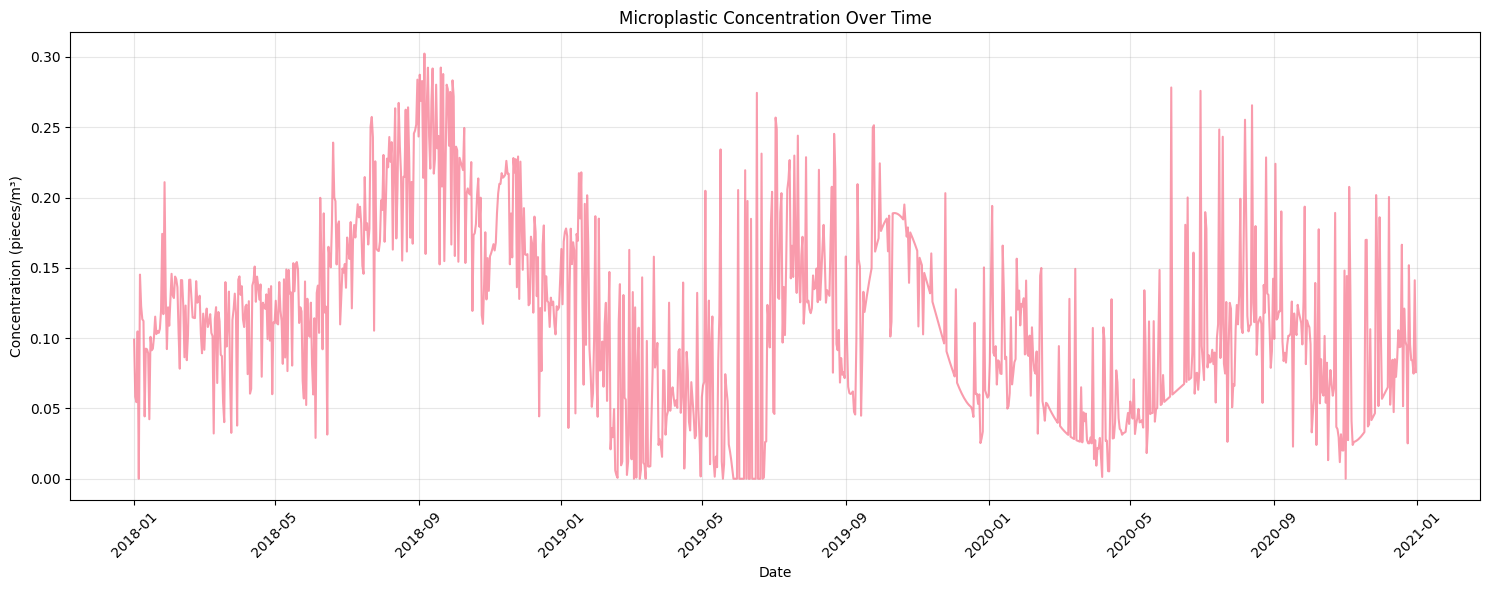

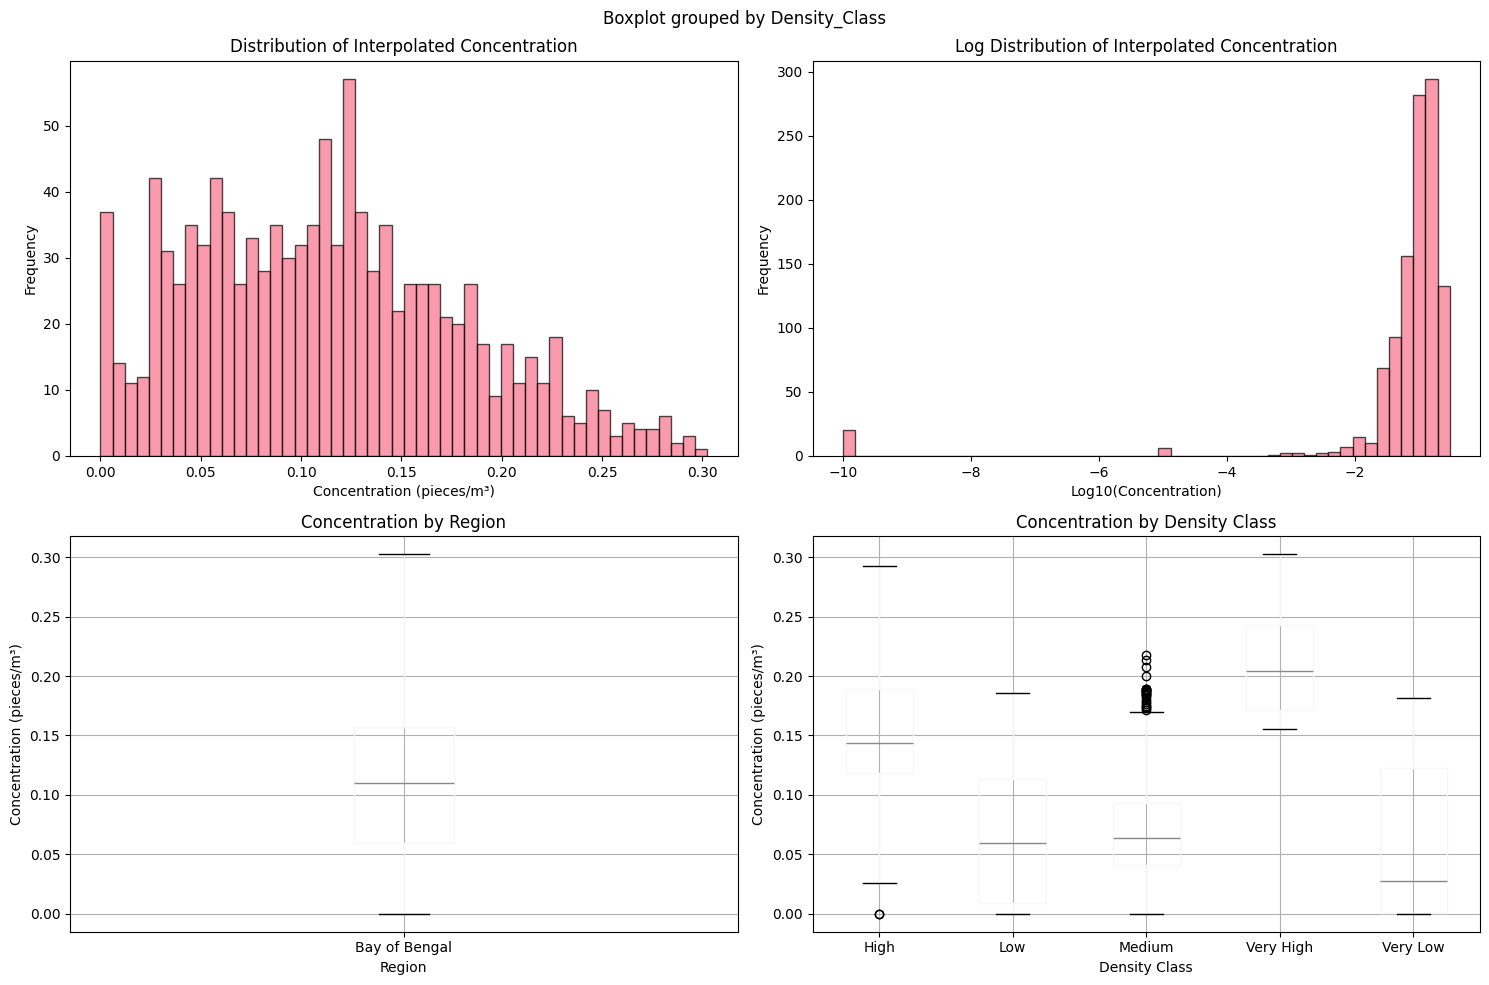

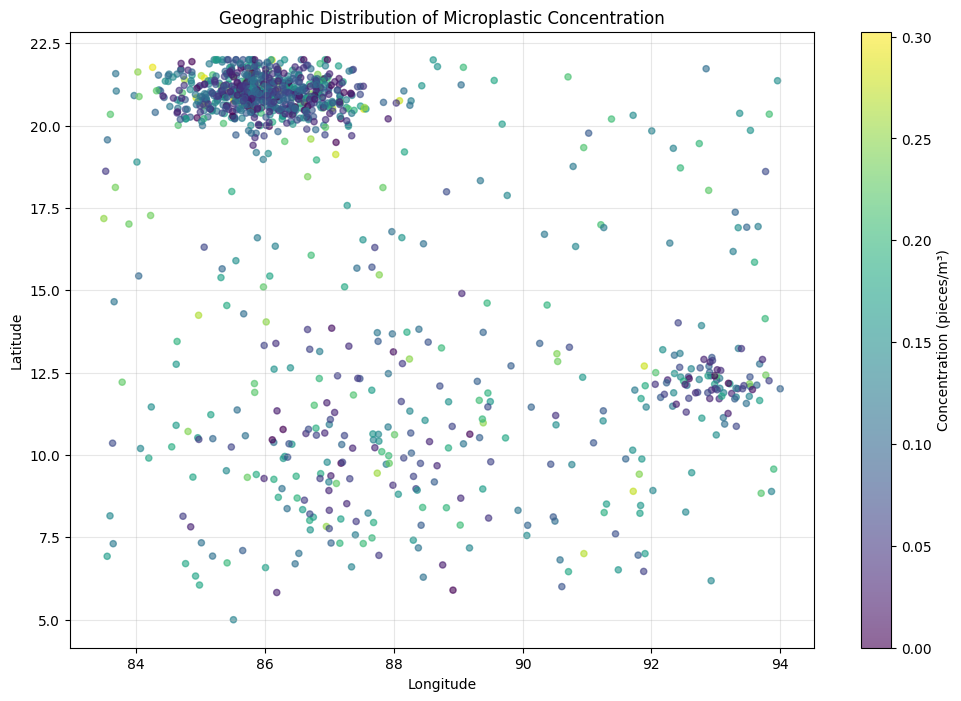

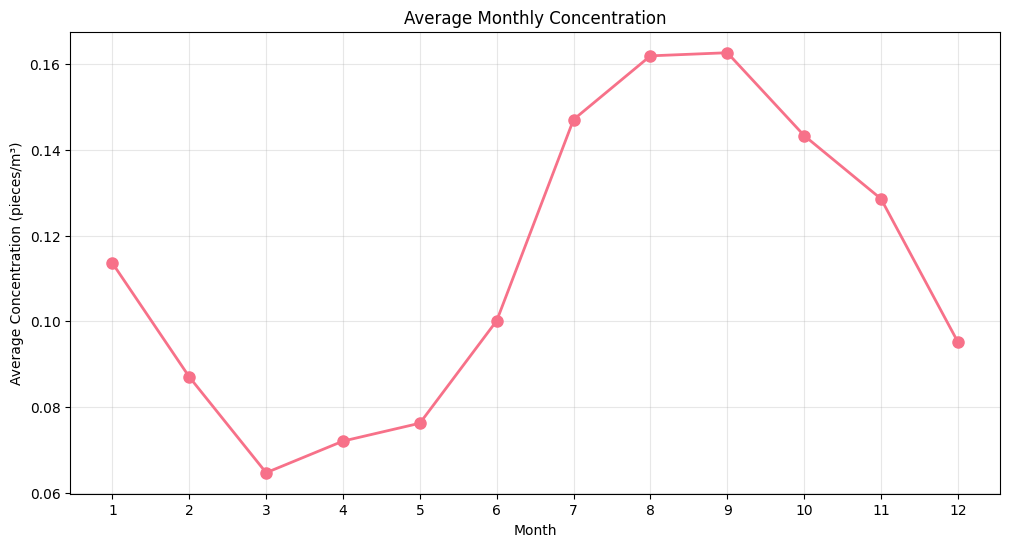

In [12]:
# Set up the plotting style
plt.style.use('default')
sns.set_palette("husl")

# 1. Time series plot
plt.figure(figsize=(15, 6))
plt.plot(df['Date'], df['Interpolated_Concentration'], alpha=0.7)
plt.title('Microplastic Concentration Over Time')
plt.xlabel('Date')
plt.ylabel('Concentration (pieces/m³)')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 2. Distribution plots
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Concentration histogram
axes[0,0].hist(df['Interpolated_Concentration'], bins=50, alpha=0.7, edgecolor='black')
axes[0,0].set_title('Distribution of Interpolated Concentration')
axes[0,0].set_xlabel('Concentration (pieces/m³)')
axes[0,0].set_ylabel('Frequency')

# Log scale histogram
axes[0,1].hist(np.log10(df['Interpolated_Concentration'] + 1e-10), bins=50, alpha=0.7, edgecolor='black')
axes[0,1].set_title('Log Distribution of Interpolated Concentration')
axes[0,1].set_xlabel('Log10(Concentration)')
axes[0,1].set_ylabel('Frequency')

# Box plot by region
df.boxplot(column='Interpolated_Concentration', by='Region', ax=axes[1,0])
axes[1,0].set_title('Concentration by Region')
axes[1,0].set_xlabel('Region')
axes[1,0].set_ylabel('Concentration (pieces/m³)')

# Box plot by density class
df.boxplot(column='Interpolated_Concentration', by='Density_Class', ax=axes[1,1])
axes[1,1].set_title('Concentration by Density Class')
axes[1,1].set_xlabel('Density Class')
axes[1,1].set_ylabel('Concentration (pieces/m³)')

plt.tight_layout()
plt.show()

# 3. Geographic scatter plot
plt.figure(figsize=(12, 8))
scatter = plt.scatter(df['Longitude'], df['Latitude'], 
                     c=df['Interpolated_Concentration'], 
                     cmap='viridis', alpha=0.6, s=20)
plt.colorbar(scatter, label='Concentration (pieces/m³)')
plt.title('Geographic Distribution of Microplastic Concentration')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.grid(True, alpha=0.3)
plt.show()

# 4. Seasonal analysis
plt.figure(figsize=(12, 6))
monthly_avg = df.groupby('Month')['Interpolated_Concentration'].mean()
plt.plot(monthly_avg.index, monthly_avg.values, marker='o', linewidth=2, markersize=8)
plt.title('Average Monthly Concentration')
plt.xlabel('Month')
plt.ylabel('Average Concentration (pieces/m³)')
plt.xticks(range(1, 13))
plt.grid(True, alpha=0.3)
plt.show()

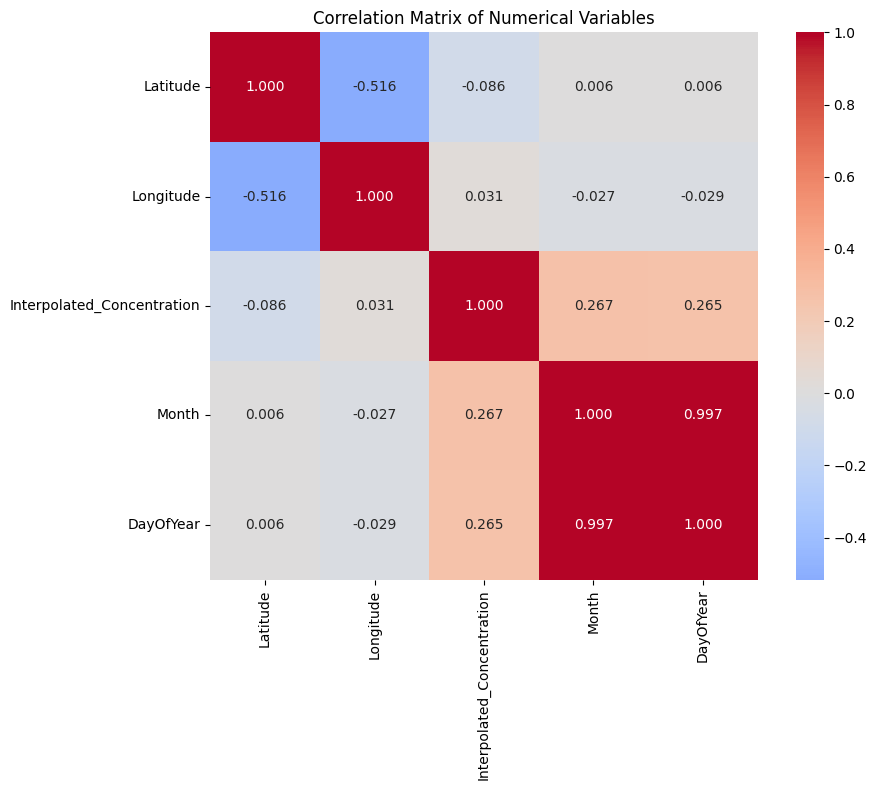

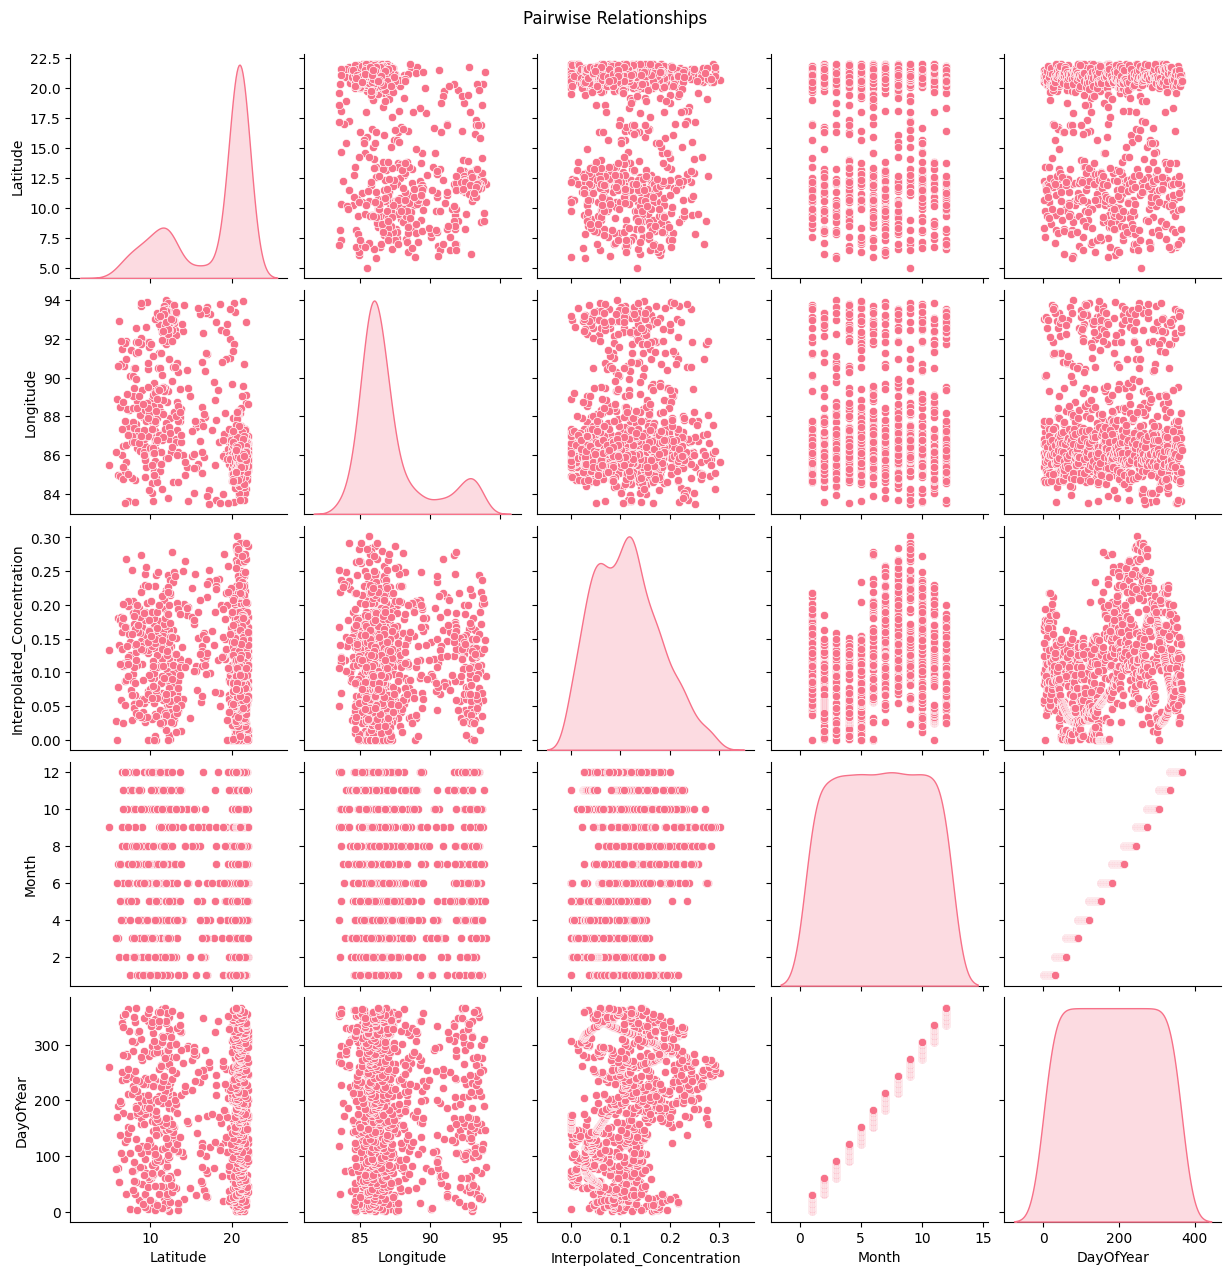

In [13]:
# Correlation matrix for numerical variables
numerical_cols = ['Latitude', 'Longitude', 'Interpolated_Concentration', 'Month', 'DayOfYear']
correlation_matrix = df[numerical_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, fmt='.3f')
plt.title('Correlation Matrix of Numerical Variables')
plt.tight_layout()
plt.show()

# Pairwise relationships
sns.pairplot(df[numerical_cols], diag_kind='kde')
plt.suptitle('Pairwise Relationships', y=1.02)
plt.show()

In [14]:
# Analyze interpolated vs original data
interpolated_data = df[df['Is_Interpolated'] == True]
original_data = df[df['Is_Interpolated'] == False]

print(f"Total data points: {len(df)}")
print(f"Original data points: {len(original_data)} ({len(original_data)/len(df)*100:.1f}%)")
print(f"Interpolated data points: {len(interpolated_data)} ({len(interpolated_data)/len(df)*100:.1f}%)")

# Compare statistics
print("\nOriginal vs Interpolated Statistics:")
comparison = pd.DataFrame({
    'Original': original_data['Interpolated_Concentration'].describe(),
    'Interpolated': interpolated_data['Interpolated_Concentration'].describe()
})
print(comparison)

Total data points: 1096
Original data points: 588 (53.6%)
Interpolated data points: 508 (46.4%)

Original vs Interpolated Statistics:
         Original  Interpolated
count  588.000000    508.000000
mean     0.111725      0.114178
std      0.066352      0.066350
min      0.000010      0.000000
25%      0.059963      0.059709
50%      0.107938      0.111940
75%      0.146423      0.164997
max      0.302361      0.278247


Shapiro-Wilk test: statistic=0.9772, p-value=0.0000

Outlier Analysis:
Number of outliers: 0 (0.00%)
Outlier range: nan to nan


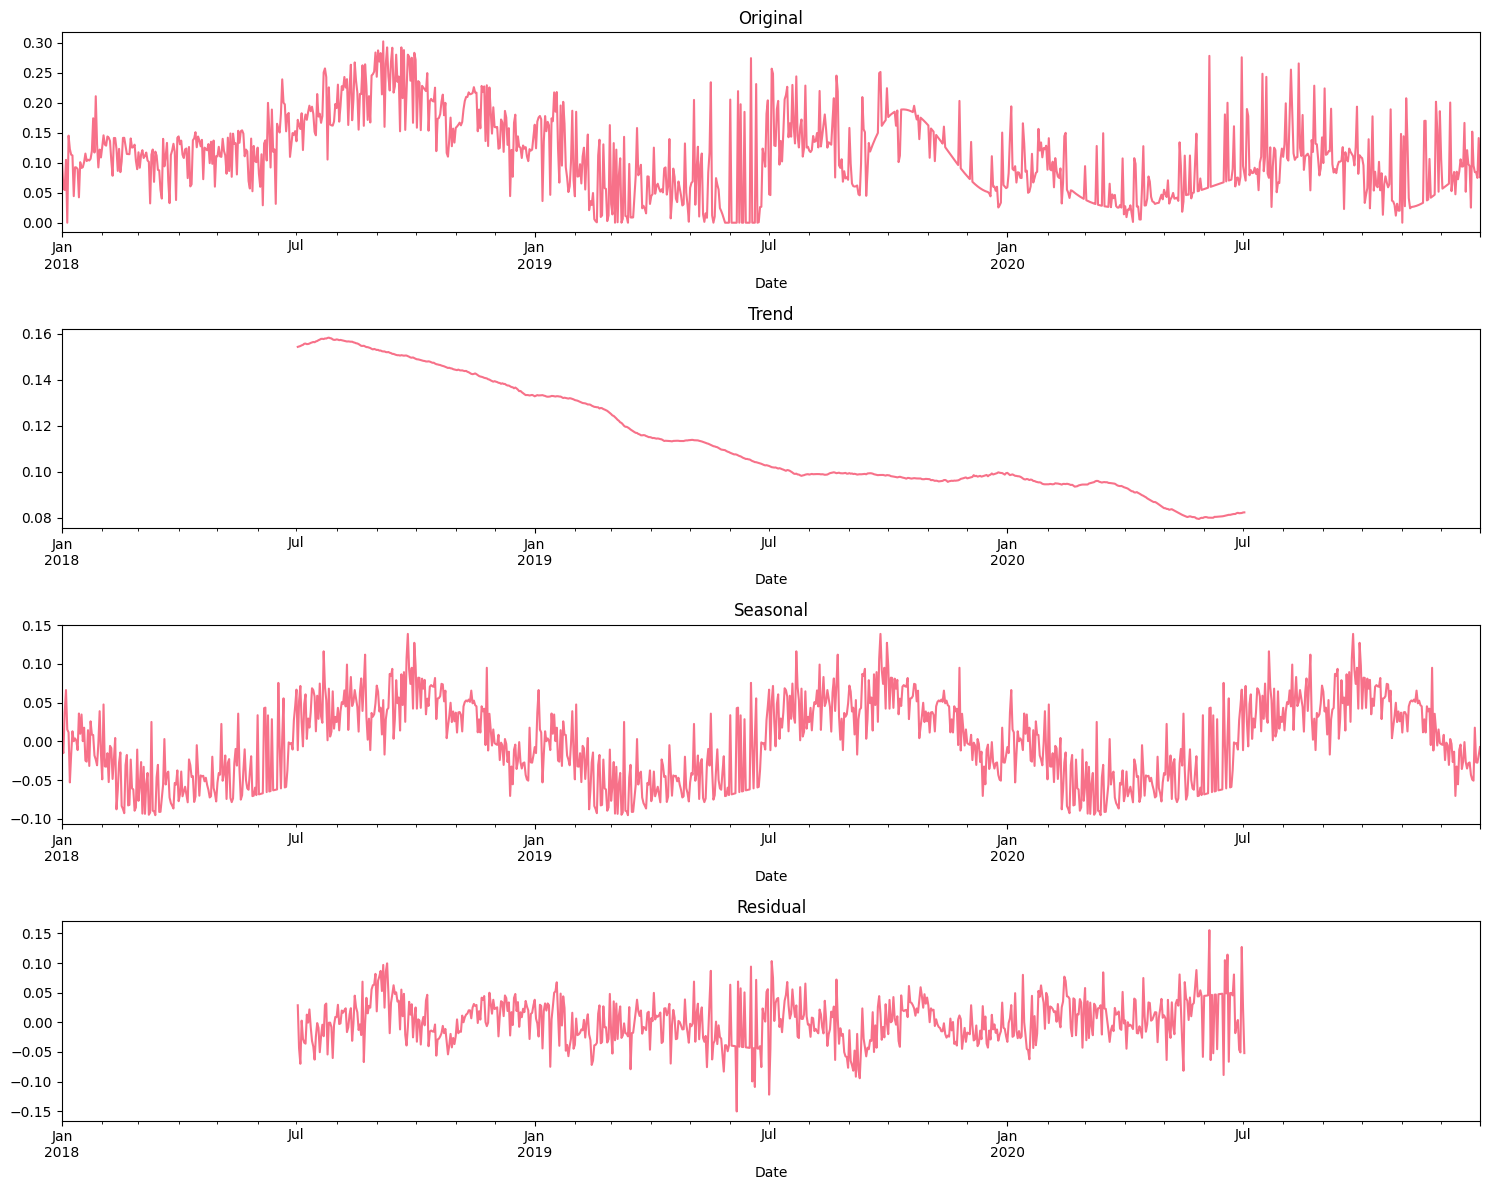

In [16]:
from scipy import stats

# Normality tests
concentration = df['Interpolated_Concentration']
shapiro_stat, shapiro_p = stats.shapiro(concentration)  # Sample for large datasets
print(f"Shapiro-Wilk test: statistic={shapiro_stat:.4f}, p-value={shapiro_p:.4f}")

# Outlier detection using IQR
Q1 = concentration.quantile(0.25)
Q3 = concentration.quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = concentration[(concentration < lower_bound) | (concentration > upper_bound)]
print(f"\nOutlier Analysis:")
print(f"Number of outliers: {len(outliers)} ({len(outliers)/len(concentration)*100:.2f}%)")
print(f"Outlier range: {outliers.min():.6f} to {outliers.max():.6f}")

# Time series decomposition (if you want to add this)
from statsmodels.tsa.seasonal import seasonal_decompose

# Resample to daily data for decomposition
daily_data = df.set_index('Date')['Interpolated_Concentration'].resample('D').mean()
decomposition = seasonal_decompose(daily_data.dropna(), model='additive', period=365)

fig, axes = plt.subplots(4, 1, figsize=(15, 12))
decomposition.observed.plot(ax=axes[0], title='Original')
decomposition.trend.plot(ax=axes[1], title='Trend')
decomposition.seasonal.plot(ax=axes[2], title='Seasonal')
decomposition.resid.plot(ax=axes[3], title='Residual')
plt.tight_layout()
plt.show()

In [17]:
# Generate summary statistics
summary_stats = {
    'Dataset_Info': {
        'Total_Records': len(df),
        'Date_Range': f"{df['Date'].min().strftime('%Y-%m-%d')} to {df['Date'].max().strftime('%Y-%m-%d')}",
        'Geographic_Coverage': f"Lat: {df['Latitude'].min():.2f} to {df['Latitude'].max():.2f}, Lon: {df['Longitude'].min():.2f} to {df['Longitude'].max():.2f}",
        'Missing_Values': df.isnull().sum().sum(),
        'Interpolated_Percentage': (df['Is_Interpolated'].sum() / len(df)) * 100
    },
    'Concentration_Stats': {
        'Mean': df['Interpolated_Concentration'].mean(),
        'Median': df['Interpolated_Concentration'].median(),
        'Std': df['Interpolated_Concentration'].std(),
        'Min': df['Interpolated_Concentration'].min(),
        'Max': df['Interpolated_Concentration'].max(),
        'Skewness': df['Interpolated_Concentration'].skew(),
        'Kurtosis': df['Interpolated_Concentration'].kurtosis()
    }
}

print("=== DATASET ANALYSIS SUMMARY ===")
for category, stats in summary_stats.items():
    print(f"\n{category}:")
    for key, value in stats.items():
        print(f"  {key}: {value}")

=== DATASET ANALYSIS SUMMARY ===

Dataset_Info:
  Total_Records: 1096
  Date_Range: 2018-01-01 to 2020-12-31
  Geographic_Coverage: Lat: 5.00 to 22.00, Lon: 83.50 to 94.00
  Missing_Values: 508
  Interpolated_Percentage: 46.35036496350365

Concentration_Stats:
  Mean: 0.11286237692145347
  Median: 0.1101021699761774
  Std: 0.06633188444622187
  Min: 0.0
  Max: 0.302360708327387
  Skewness: 0.40722845635116844
  Kurtosis: -0.4148382706425098
